In [1]:
import os
import pickle
import joblib
import math
import hdbscan
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import Birch, AgglomerativeClustering
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import coo_matrix


In [2]:
nnary_df = pd.read_csv("./output/nnary_features.csv").set_index("filename")
nnary_df

,uni_1_count,uni_1_total_area,uni_1_avg_x,uni_1_avg_y,uni_2_count,uni_2_total_area,uni_2_avg_x,uni_2_avg_y,uni_3_count,uni_3_total_area,...,tri_5_7_8_count,tri_5_7_8_area_ratio_ij,tri_5_7_8_area_ratio_jk,tri_5_7_8_avg_x,tri_5_7_8_avg_y,tri_6_7_8_count,tri_6_7_8_area_ratio_ij,tri_6_7_8_area_ratio_jk,tri_6_7_8_avg_x,tri_6_7_8_avg_y
filename,,,,,,,,,,,,,,,,,,,,,
40795.png,2.0,3396.0,-38.604240,53.561837,1.0,2542.0,72.000000,60.500000,1,6998.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60259.png,NaN,NaN,NaN,NaN,1.0,6864.0,-46.000000,4.000000,1,3596.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45409.png,2.0,4462.0,-2.314433,115.000000,1.0,2156.0,-31.000000,4.500000,1,5624.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22733.png,1.0,1855.0,43.500000,80.500000,1.0,2560.0,87.000000,65.000000,1,6431.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25886.png,1.0,1591.0,72.500000,46.500000,1.0,2433.5,73.436340,99.513321,1,6373.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26753.png,1.0,2135.5,39.887224,53.269570,1.0,2359.5,18.394646,150.781027,1,6447.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42387.png,1.0,2378.0,-76.000000,37.500000,1.0,2575.0,-101.982524,85.307702,1,8847.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19466.png,2.0,3132.0,49.873563,51.637931,NaN,NaN,NaN,NaN,1,6677.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
nnary_df = nnary_df.fillna(0)

nnary_df = nnary_df.loc[:, ~(nnary_df == 0).all()]

In [4]:
nnary_sans78_df = nnary_df.loc[:, ~nnary_df.columns.str.contains(r'7|8')]

In [12]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(nnary_sans78_df),
    index=nnary_sans78_df.index,
    columns=nnary_sans78_df.columns
)

X = df_scaled.values
X

array([[ 9.17179551e-01,  3.70101426e-01, -7.39991613e-01, ...,
        -2.18719555e-01, -2.23366106e-03, -1.85529931e-01],
       [-2.62673591e+00, -2.53616291e+00, -2.31607854e-02, ...,
        -2.18719555e-01, -2.23366106e-03, -1.85529931e-01],
       [ 9.17179551e-01,  1.28237404e+00, -6.61368136e-02, ...,
        -2.18719555e-01, -2.23366106e-03, -1.85529931e-01],
       ...,
       [ 9.17179551e-01,  1.44172750e-01,  9.02926798e-01, ...,
        -2.18719555e-01, -2.23366106e-03, -1.85529931e-01],
       [ 9.17179551e-01,  1.05516167e+00, -3.88141816e-01, ...,
        -2.18719555e-01, -2.23366106e-03, -1.85529931e-01],
       [ 9.17179551e-01,  1.24300768e+00, -1.93896695e+00, ...,
        -2.18719555e-01, -2.23366106e-03, -1.85529931e-01]])

In [ ]:
scaler = StandardScaler()
Xc = scaler.fit_transform(nnary_sans78_df)   

# Xc = nnary_sans78_df - nnary_sans78_df.mean(axis=0)

C = np.cov(Xc, rowvar=False)

eigvals, eigvecs = np.linalg.eigh(C)
eps = 1e-5   
D_half_inv = np.diag(1.0 / np.sqrt(eigvals + eps))

W_zca = eigvecs @ D_half_inv @ eigvecs.T

X_zca = Xc @ W_zca

df_zca = pd.DataFrame(X_zca,
                      index=nnary_sans78_df.index,
                      columns=nnary_sans78_df.columns)

In [6]:
off_diag = W_zca.copy()
np.fill_diagonal(off_diag, 0)
print("max off-diagonal weight:", np.abs(off_diag).max())

max off-diagonal weight: 10.772184720453811


In [7]:
threshold = 0.01
W_sparse = np.where(np.abs(W_zca) < threshold, 0, W_zca)
# df_zca_sparse = pd.DataFrame(Xc.values @ W_sparse,
#                              index=nnary_sans78_df.index,
#                              columns=nnary_sans78_df.columns)
df_zca_sparse = pd.DataFrame(Xc @ W_sparse,
                             index=nnary_sans78_df.index,
                             columns=nnary_sans78_df.columns)

In [13]:
num_data = 40000

# non zca
df_zca = pd.DataFrame(X,
                      index=nnary_sans78_df.index,
                      columns=nnary_sans78_df.columns)

# # non sparse zca
df_zca_sparse = df_zca[:]
df_zca_sparse_subset = df_zca_sparse[:num_data]
X = df_zca_sparse_subset.values

In [ ]:
n_clusters = 20 
sc = SpectralClustering(
    n_clusters=n_clusters,
    affinity='nearest_neighbors',
    random_state=42
)
labels = sc.fit_predict(X)
df_zca_sparse_subset['cluster'] = labels

cluster_means = df_zca_sparse_subset.groupby('cluster').mean()
global_mean   = df_zca_sparse_subset.drop(columns='cluster').mean()

mean_diff = cluster_means.sub(global_mean, axis=1)



/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Cluster means:
          uni_1_count  uni_1_total_area  uni_1_avg_x  uni_1_avg_y  uni_2_count  \
cluster                                                                         
0           0.101326          0.011056     0.068223     0.026384     0.025690   
1          -0.504923         -0.373696    -0.004928    -0.252495     0.366558   
2           0.008650         -0.012218    -0.001083    -0.056422     0.095139   
3           0.146461          0.141822    -0.023801    -0.144056     0.080273   
4          -0.341269         -0.340660     0.053921     0.297306     0.056406   
5           0.165054         -0.122633    -0.051484     0.208689    -0.112859   
6           0.754629          0.597144    -0.020368     0.354882     0.040192   
7          -0.375012         -0.410679     0.000779    -0.094634     0.057807   
8          -0.464056         -0.404880     0.073577    -0.109889     0.093480   
9           0.436416          0.285829     0.070360     0.155628    -0.127333   
10          

/tmp/ipykernel_141314/958844246.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_zca_sparse_subset['cluster'] = labels


In [3]:
top_feat_scores = {}
for cluster in mean_diff.index:
    sorted_vals = mean_diff.loc[cluster].abs().sort_values(ascending=False).head(10)
    top_feat_scores[cluster] = sorted_vals

rows = {}
for cluster, series in top_feat_scores.items():
    feats = series.index.tolist()
    scores = series.values.tolist()
    row = {}
    for i, (f, s) in enumerate(zip(feats, scores), start=1):
        row[f"Feature {i}"] = f
        row[f"Score {i}"]   = s
    rows[cluster] = row

top_df = pd.DataFrame.from_dict(rows, orient='index')
top_df.index.name = 'cluster'

print(top_df)

NameError: name 'mean_diff' is not defined

In [4]:
df_zca_sparse_subset['cluster'].value_counts()

NameError: name 'df_zca_sparse_subset' is not defined

In [10]:
linked = sch.linkage(X[:num_data], method='ward')

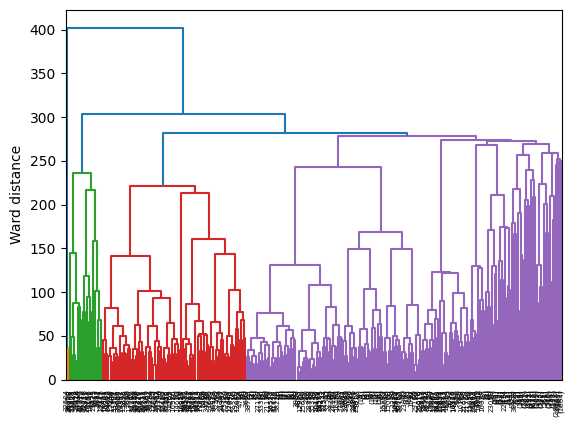

In [11]:
sch.dendrogram(linked, truncate_mode='level', p=10)
plt.ylabel("Ward distance")
plt.show()

In [12]:
clusterer = AgglomerativeClustering(n_clusters=20, linkage='ward')
labels = clusterer.fit_predict(X[:num_data])

In [13]:
# cnt = Counter(list(labels) + list(labels_rest))
cnt = Counter(list(labels))
for lbl, count in sorted(cnt.items()):
    if lbl == -1:
        print(f"  Noise points: {count}")
    else:
        print(f"  Cluster {lbl:>2}: {count} plans")

  Cluster  0: 26965 plans
  Cluster  1: 1932 plans
  Cluster  2: 503 plans
  Cluster  3: 3676 plans
  Cluster  4: 1444 plans
  Cluster  5: 425 plans
  Cluster  6: 13 plans
  Cluster  7: 174 plans
  Cluster  8: 917 plans
  Cluster  9: 116 plans
  Cluster 10: 437 plans
  Cluster 11: 39 plans
  Cluster 12: 1664 plans
  Cluster 13: 967 plans
  Cluster 14: 347 plans
  Cluster 15: 2 plans
  Cluster 16: 174 plans
  Cluster 17: 10 plans
  Cluster 18: 187 plans
  Cluster 19: 8 plans


In [14]:
X[:num_data, :].shape

(40000, 184)

In [15]:
k_final = 20
num_data = 40000
cluster_centroids_16 = np.zeros((k_final, X.shape[1]), dtype=float)
X_first_n = X[:num_data]
for k in range(k_final):
    members = (labels == k)
    if np.any(members):
        cluster_centroids_16[k] = X_first_n[members].mean(axis=0)
    else:
        cluster_centroids_16[k] = 0.0

In [16]:
colnames = nnary_sans78_df.columns

In [17]:
topn = 20
top_features_per_cluster = {}
for k in range(k_final):
    centroid_vals = cluster_centroids_16[k]
    top_indices = np.argsort(centroid_vals)[-topn:][::-1]
    top_features = [(colnames[idx], centroid_vals[idx]) for idx in top_indices]
    top_features_per_cluster[k] = top_features

    print(f"\nCluster {k} — top {topn} features (feature_name, z‐score):")
    for feat_name, zval in top_features:
        print(f"  {feat_name:30s}  {zval:6.2f}")


Cluster 0 — top 20 features (feature_name, z‐score):
  bi_3_6_count                      0.07
  bi_3_4_area_ratio                 0.05
  bi_1_3_count                      0.04
  bi_2_3_count                      0.04
  tri_1_3_5_avg_y                   0.04
  bi_3_6_area_ratio                 0.03
  bi_3_5_area_ratio                 0.03
  tri_2_3_5_avg_y                   0.03
  bi_3_5_count                      0.03
  uni_5_avg_y                       0.03
  tri_3_4_6_avg_y                   0.03
  bi_1_5_area_ratio                 0.03
  bi_2_5_count                      0.03
  bi_3_5_avg_y                      0.02
  tri_2_3_4_area_ratio_ij           0.02
  bi_2_5_avg_y                      0.02
  tri_1_3_4_count                   0.02
  tri_1_3_6_count                   0.02
  bi_2_5_area_ratio                 0.02
  tri_3_4_6_area_ratio_ij           0.02

Cluster 1 — top 20 features (feature_name, z‐score):
  bi_4_5_count                      2.28
  tri_4_5_6_count              

In [18]:
N = 20
under_features_per_cluster = {}

for k in range(k_final):
    centroid_vals = cluster_centroids_16[k]

    neg_indices = np.argsort(centroid_vals)[:N]
    neg_feats = [(colnames[idx], centroid_vals[idx]) for idx in neg_indices]
    under_features_per_cluster[k] = neg_feats

    print(f"\nCluster {k} — top {N} under‐represented features (name, z‐score):")
    for feat_name, zval in neg_feats:
        print(f"  {feat_name:30s} {zval:6.2f}")


Cluster 0 — top 20 under‐represented features (name, z‐score):
  tri_1_2_4_count                 -0.18
  tri_1_4_6_count                 -0.15
  bi_4_5_count                    -0.15
  tri_1_2_4_area_ratio_ij         -0.15
  tri_2_3_6_count                 -0.14
  tri_1_2_4_area_ratio_jk         -0.13
  bi_2_6_count                    -0.13
  tri_4_5_6_count                 -0.11
  bi_4_5_area_ratio               -0.11
  tri_2_3_6_area_ratio_jk         -0.10
  tri_1_2_5_area_ratio_ij         -0.10
  bi_1_4_count                    -0.09
  bi_4_6_count                    -0.09
  tri_1_2_5_count                 -0.09
  tri_1_4_6_area_ratio_jk         -0.08
  tri_1_2_5_avg_y                 -0.08
  tri_1_2_4_avg_y                 -0.08
  tri_1_4_6_area_ratio_ij         -0.08
  tri_3_4_5_count                 -0.08
  tri_2_3_6_avg_y                 -0.07

Cluster 1 — top 20 under‐represented features (name, z‐score):
  tri_3_4_5_count                 -0.73
  tri_2_4_5_count               

In [22]:
filenames = nnary_sans78_df.index

In [23]:
cosim_matrix = cosine_similarity(X, cluster_centroids_16) 
cosim_matrix.shape

cosim_colnames = [f"cos_sim_{k}" for k in range(k_final)]
df_cosim = pd.DataFrame(cosim_matrix, index=filenames, columns=cosim_colnames)

df_features = pd.DataFrame(X, index=filenames, columns=colnames)

In [24]:
df_result = pd.concat([df_cosim, df_features, ], axis=1)[:num_data]
df_result['cluster'] = labels

In [25]:
df_result = df_result[[df_result.columns[-1]] + list(df_result.columns[:-1])]

In [26]:
df_result.to_csv("clustering_result_nnary.csv")

In [27]:
df_result[:1000].to_csv("clustering_result_nnary_first1000.csv")